### **1.Familiarize yourself with the data. Load and visualize the input data for a few floorplans using a seperate Python script, Jupyter notebook or your preferred too**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

First we plot the grids.

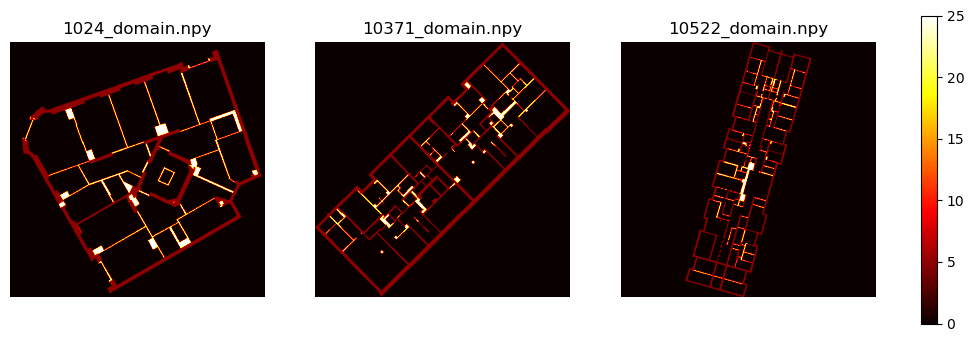

In [33]:
folder = "modified_swiss_dwellings"
domain_files = sorted([f for f in os.listdir(folder) if f.endswith("_domain.npy")])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    data = np.load(os.path.join(folder, domain_files[i]))
    
    im = axes[i].imshow(data, cmap='hot')
    axes[i].set_title(domain_files[i])
    axes[i].axis("off")

# one shared colorbar
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)

plt.show()

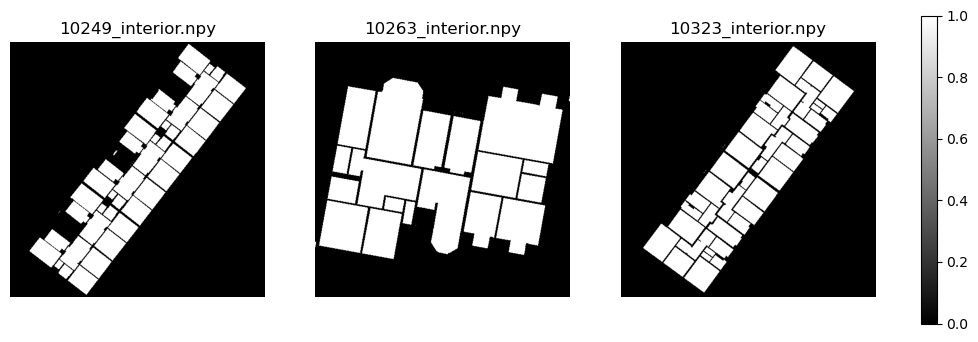

In [36]:
folder = "modified_swiss_dwellings"
interior_files = sorted([f for f in os.listdir(folder) if f.endswith("_interior.npy")])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    data = np.load(os.path.join(folder, interior_files[i]))
    
    im = axes[i].imshow(data, cmap='gray')
    axes[i].set_title(interior_files[i])
    axes[i].axis("off") 

# shared colorbar (optional here)
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)

plt.show()

### **2. Familiarize yourself with the provided script. Run and time the reference implementation for a small subset of floorplans (e.g., 10 - 20). How long do you estimate it would take to process all the floorplans? Perform the timing as a batch job so you get relieable result**

Uploaded simulate.py and job.sh onto the HPC, and we chose to run with a subset of 10 for now. Below is the output:
```bash
Your job looked like:

------------------------------------------------------------
# LSBATCH: User input
#!/bin/bash
#BSUB -J timing_test
#BSUB -q hpc
#BSUB -n 1
#BSUB -W 00:10
#BSUB -R "rusage[mem=2GB]"
#BSUB -o output.txt

echo "Starting job"
date

python simulate.py 10

date
echo "Finished job"
------------------------------------------------------------

Successfully completed.

Resource usage summary:

    CPU time :                                   113.72 sec.
    Max Memory :                                 72 MB
    Average Memory :                             67.33 MB
    Total Requested Memory :                     2048.00 MB
    Delta Memory :                               1976.00 MB
    Max Swap :                                   -
    Max Processes :                              4
    Max Threads :                                5
    Run time :                                   116 sec.
    Turnaround time :                            117 sec.

The output (if any) is above this job summary.
```

So 10 buildings took around 116 seconds with these stats and there are 4571 buildings, so one building took:
$$
116 \text{ seconds} / 10 \text{ buildings} = 11.6 \text{ seconds/building}
$$
Thus:
$$
4571 \text{ buildings} \times 11.6 \text{ seconds/building} = 53023.6 \text{ seconds} \approx 14.73 \text{ hours}
$$
So, running the reference implementation on 10 buildings took approximately 116 seconds.
Assuming linear scaling, processing all 4571 buildings is estimated to take around 14–15 hours on a single core.

### **3. Visualize the simulation results for a few floorplans.**

In [13]:
# We reuse some functions from simulate.py

from os.path import join
import numpy as np

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def jacobi(u, interior_mask, max_iter=20000, atol=1e-4):
    u = np.copy(u)
    for _ in range(max_iter):
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior
        if delta < atol:
            break
    return u

In [22]:
folder = "modified_swiss_dwellings"
files = os.listdir(folder)

domain_files = [f for f in files if f.endswith("_domain.npy")]
interior_files = [f for f in files if f.endswith("_interior.npy")]

# extract IDs
domain_ids = set(f.replace("_domain.npy", "") for f in domain_files)
interior_ids = set(f.replace("_interior.npy", "") for f in interior_files)

# only keep IDs that have BOTH files
valid_ids = list(domain_ids.intersection(interior_ids))

print(f"Found {len(valid_ids)} valid buildings")

bid = valid_ids[0]

Found 4 valid buildings


In [26]:
u0, interior_mask = load_data(folder, bid)
u = jacobi(u0, interior_mask)

Now for plotting.

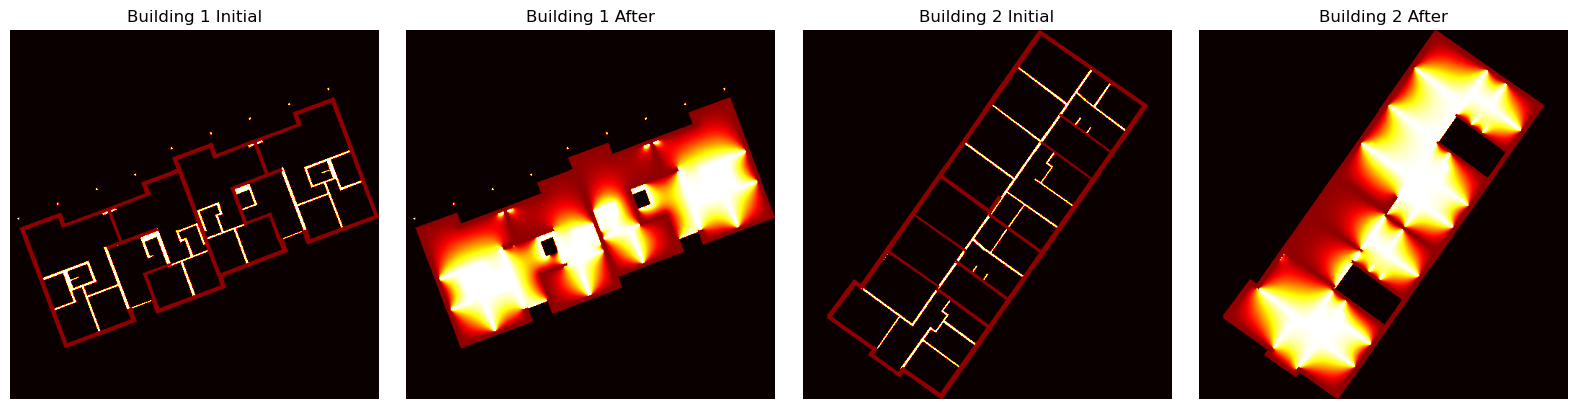

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, bid in enumerate(valid_ids[:2]):
    u0, interior_mask = load_data(folder, bid)
    u = jacobi(u0, interior_mask)

    # Initial
    axes[2*i].imshow(u0[1:-1, 1:-1], cmap='hot', vmin=0, vmax=25)
    axes[2*i].set_title(f"Building {i+1} Initial")
    axes[2*i].axis("off")

    # After
    axes[2*i + 1].imshow(u[1:-1, 1:-1], cmap='hot', vmin=0, vmax=25)
    axes[2*i + 1].set_title(f"Building {i+1} After")
    axes[2*i + 1].axis("off")

plt.tight_layout()
plt.show()

### **4. Profile the reference jacobi function using kernprof. Explain the different parts of the function and how much time each part takes**

We just add profiling to the simulate.py file so writing @profile before the jacobi function, and then we also change the job script to:
```bash
#!/bin/bash
#BSUB -J timing_test
#BSUB -q hpc
#BSUB -n 1
#BSUB -W 00:10
#BSUB -R "rusage[mem=2GB]"
#BSUB -o output.txt

cd $LS_SUBCWD

echo "Starting job"
date

echo "CPU model:"
grep "model name" /proc/cpuinfo | head -n 1

echo "Running kernprof now!!!"

kernprof -l simulate.py 5

echo "Profiling results:"
python3 -m line_profiler simulate.py.lprof

date
echo "Finished job"
```

We get:
```bash
Total time: 58.0747 s
File: simulate_profile.py
Function: jacobi at line 14

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    14                                           @profile
    15                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):
    16         5       3232.3    646.5      0.0      u = np.copy(u)
    17                                           
    18     28423      23907.5      0.8      0.0      for i in range(max_iter):
    19                                                   # Compute average of left, right, up and down neighbors, see eq. (1)
    20     28423   31351691.6   1103.0     54.0          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
    21     28423    6718444.0    236.4     11.6          u_new_interior = u_new[interior_mask]
    22     28423   12886472.3    453.4     22.2          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
    23     28423    7044857.8    247.9     12.1          u[1:-1, 1:-1][interior_mask] = u_new_interior
    24                                           
    25     28423      46103.6      1.6      0.1          if delta < atol:
    26         5          4.1      0.8      0.0              break
    27         5          1.5      0.3      0.0      return u

Thu Apr  9 12:22:37 CEST 2026
Finished job
```

The profiling results show that the majority of execution time is spent inside the main iteration loop of the Jacobi method.

The most time-consuming operation is the computation of the neighbor average:

> The line computing u_new accounts for approximately 54% of the total runtime.

> This operation involves multiple NumPy array slices and element-wise additions, making it computationally expensive due to large memory access and data movement.

The second most expensive operation is the convergence check:

> The computation of delta takes around 22% of the runtime.

> This includes slicing, masking, subtraction, and a reduction (max()), which together create significant overhead.

Other notable costs include:

> Updating the interior values (`u[...] = u_new_interior`), which takes about 12%.

> Extracting interior values (`u_new[interior_mask]`), which takes about 11%. These operations involve masked indexing, which is relatively slow due to non-contiguous memory access.

Finally, operations such as copying the array and checking the stopping condition contribute negligibly to the total runtime. BUT MOST IMPORTANTLY is that the performance bottleneck is dominated by NumPy array operations and memory access, not Python control flow.

### **5. Make a new Python program where you parallelize the computations over the floorplans. Use static scheduling such that each worker is assigned the same amount of floorplans to process.**

If we look here:
```python
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u
```
We see that each building floorplan is independent because we only call on `i` meaning that this part is parallelizable.

We want to split buildings evenly across workers and each worker processes a fixed chunk (notes for the report btw). Check the code for changes, which are marked with # TASK 5.

The functions here:
```python
#############
# TASK 5.1
def process_building(i):
    u0 = all_u0[i]
    interior_mask = all_interior_mask[i]
    return jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)

def run_parallel(N, num_workers):
    with Pool(processes=num_workers) as pool:
        results = pool.map(process_building, range(N))
    return np.array(results)
# TASK 5.1
#############
```

So `process_building` checks for building with index `i` and finds their corresponding interior masks, then we call the `jacobi` function on that building and return the result after steady-state temperature distribution. 

Then in `run_parallel`, we create a multiprocessing pool where we can specify num workers, and we use `pool.map` to apply `process_building` to each building index from 0 to N-1. Each worker process handles a subset of the buildings independently, and the results are collected and returned as a numpy array. Now since each building can be processed independently, this approach uses data-level parallelism across floorplans. Static scheduling is achieved through `pool.map`, which distributes the workload evenly among the worker processes (notes for the report maybe?).

##### **5.1 Measure the speed-up as more workers are added. Plot your speed-ups.**


We just create 4 job scripts going for 1, 2, 4, and 8 workers, and then we can plot the speedup results, see folder task_5_1_jobs for the scripts and the output files.

(example upload copypasteable `scp job_4.sh s224215@login.hpc.dtu.dk:/zhome/76/c/186999/mini_project_02613/task_5/`)

(example download copypasteable `scp s224215@login.hpc.dtu.dk:/zhome/76/c/186999/mini_project_02613/task_5/out_1w.txt .`)

We have 1 worker:

Fri Apr 10 12:35:06 CEST 2026

Fri Apr 10 12:46:09 CEST 2026

So this in seconds is (12:46:09 - 12:35:06) = 663 seconds for 1 worker.

For 2 workers:

Fri Apr 10 12:35:11 CEST 2026

Fri Apr 10 12:41:06 CEST 2026

So this in seconds is (12:41:06 - 12:35:11) = 355 seconds for 2 workers.

For 4 workers:

Fri Apr 10 12:35:44 CEST 2026

Fri Apr 10 12:39:30 CEST 2026

So this in seconds is (12:39:30 - 12:35:44) = 226 seconds for 4 workers.

For 8 workers:

Fri Apr 10 12:35:49 CEST 2026

Fri Apr 10 12:37:38 CEST 2026

So this in seconds is (12:37:38 - 12:35:49) = 109 seconds for 8 workers.

Now to plot the speed ups with the formula from slides:
$$
Speedup(p) = T1 / Tp
$$

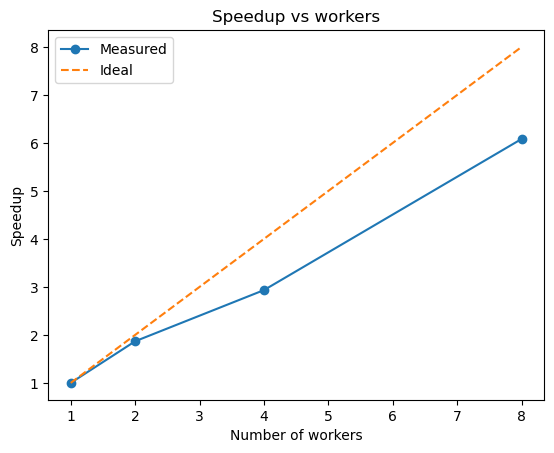

In [27]:
import matplotlib.pyplot as plt

workers = [1, 2, 4, 8]
times = [663, 355, 226, 109]

speedup = [times[0] / t for t in times]
ideal = workers

plt.plot(workers, speedup, marker='o', label="Measured")
plt.plot(workers, ideal, linestyle='--', label="Ideal")

plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup vs workers")
plt.legend()

plt.show()

##### **5.2 Estimate your parallel fraction according to Amdahl's law. How much (roughly) is parallelized?**


We have to use amdhal's law given as:
$$
S(p) = \frac{1}{(1 - F) + \frac{F}{p}}
$$
We want to find $F$.

In [30]:
p = np.array([2, 4, 8])
speedup_amdahl = np.array(speedup[1:])

f_values = (p * (1 - 1/speedup_amdahl)) / (p - 1)

print(f_values)
print("Estimated f:", np.mean(f_values))

[0.92911011 0.87883358 0.9549666 ]
Estimated f: 0.9209700974406857


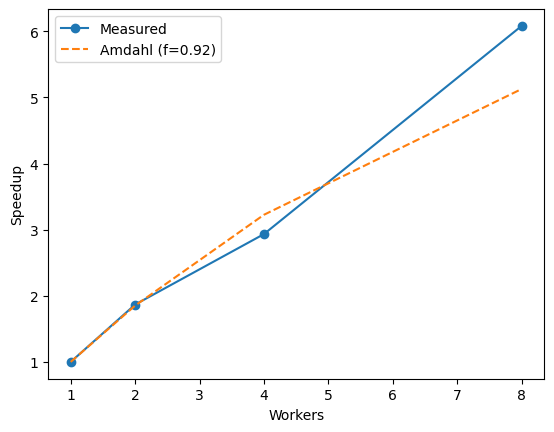

In [31]:
workers_np = np.array([1,2,4,8])
speedup = np.array([times[0]/t for t in times])

# estimated f
f = 0.92

amdahl = 1 / ((1-f) + f/workers_np)

plt.plot(workers, speedup, 'o-', label="Measured")
plt.plot(workers, amdahl, '--', label=f"Amdahl (f={f:.2f})")

plt.xlabel("Workers")
plt.ylabel("Speedup")
plt.legend()

plt.show()

The parallel fraction was estimated using Amdahl’s law based on the measured speedups. The estimated values ranged from approximately $0.89$ to $0.95$, giving an average parallel fraction of about $0.92$. This indicates that roughly $92\%$ of the computation can be parallelized, while the remaining $8\%$ is inherently serial.

##### **5.3 What is your theoretical maximum speed-up according to Amdahl's law? How much of that did you achieve? How many cores did that take?**

From slides we know the max is:
$$
S(\infty) = \frac{1}{1 - F}
$$
So inserting our value we get:
$$
S(\infty) = \frac{1}{1 - 0.92} = \frac{1}{0.08} = 12.5
$$

In [33]:
print(speedup)

[1.         1.86760563 2.93362832 6.08256881]


As we can see above we got to $6.09$, meaning that we achieved:
$$
\frac{6.09}{12.5} \approx 0.4872
$$
So $49\%$ of the theoretical maximum speedup was achieved using 8 cores.

##### **5.4 How long would you estimate it would take to process all floorplans using your fastest parallel solution?**

Earlier, we found that the total runtime for processing all 4571 buildings on a single core was previously estimated to be approximately 14.7 hours. Using the maximum observed speedup (IN OUR SETUP SCENARIO) of $6.08$ (with 8 workers), the runtime can be reduced to:
$$
T_{\text{parallel}} = \frac{14.7}{6.08} \approx 2.4 \text{ hours}
$$

Thus, using the fastest parallel configuration, the total runtime is estimated to be approximately $2–3$ hours which is around 6 times faster than the single-core estimate!.


### **6. The amount of iterations needed to reach convergence will vary from floorplan to floorplan. Re-do your parallelization experiment using dynamic scheduling.**

##### **6.1 Did it get faster? By how much?**


"The dynamic scheduling approach resulted in a slightly reduced runtime compared to static scheduling. The improvement is due to better load balancing between workers, as tasks with varying convergence times are distributed dynamically."


##### **6.2 Did the speed-up improve or worsen?**

"The speedup improved slightly when using dynamic scheduling, particularly for higher numbers of workers. This is because dynamic scheduling reduces idle time caused by uneven workload distribution in the static case."

### **7. Implement another solution where you rewrite the jacobi function using Numba JIT on the CPU.**


##### **7.1 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**


##### **7.2 Explain your function. How did you ensure your access pattern works well with the CPU cache?**


##### **7.3 How long would it now take to process all floorplans?**

### **8. Implement another solution writing a custom CUDA kernel with Numba. To synchronize threads between each iteration, the kernel should only perform a single iteration of the Jacobi solver. Skip the early stopping criteria and just run for a fixed amount of iterations. Write a helper function which takes the same inputs as the reference implementation (except for the atol input which is not needed) and then calls your kernel repeatedly to perform the implementations.**

##### **8.1 Briefly describe your new solution. How did you structure your kernel and helper function?**


##### **8.2 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**



##### **8.3 How long would it now take to process all floorplans?**

### **9. Adapt the reference solution to run on the GPU using CuPy.**


##### **9.1 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**


##### **9.2 How long would it now take to process all floorplans?**




##### **9.3 Was anything surprising about the performance?**

### **10. Profile the CuPy solution using the nsys profiler. What is the main issue regarding performance? (Hint: see exercises from week 10) Try to fix it.**

### **11. (Optional) Improve the performance of one or more of your solutions further. For example, parallelize your CPU JIT solution. Or use job arrays to parallelize a solution over multiple jobs. How fast can you get?**

### **12. Process all floorplans using one of your implementations (ideally a fast one) and answer the below questions.**

Hint: use Pandas to process the CSV results generated by the script.


##### **12.1 What is the distribution of the mean temperatures? Show your results as histograms.**


##### **12.2 What is the average mean temperature of the buildings?**


##### **12.3 What is the average temperature standard deviation?**



##### **12.4 How many buildings had at least 50% of their area above 18ºC?**



##### **12.5 How many buildings had at least 50% of their area below 15ºC?**